In [2]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from search.parallel_gradient import ParallelGradientDescent
from utils.sampling import BatchNegativeSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
#look for experiment files in parents
import os
path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)


In [4]:
experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")

In [5]:
dataset ="bigger_mnist"
default_architecutre_mapping = {
    "mnist":"resnet_small",
    "bigger_mnist":"resnet_small",
    "emnist": "extended_resnet_small",
    "bigger_emnist":"bigger_extended_resnet_small",
    "coil100":"coil_resnet_small",
    "tu_berlin":"bi_lstm",
    "modelnet10":"pointnetplus",
}
architecture = default_architecutre_mapping[dataset]
budget = 120

In [6]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info,get_dataset

dataset_info = get_dataset_info(dataset)
dataset_dict = get_dataset(dataset_info,path=experiment_files_path_data)


In [7]:
dataset_info

Box({'input_size': (1, 40, 40), 'num_classes': 10, 'transform_seq_name': 'biggermnist_default', 'datatype': 'image', 'name': 'bigger_mnist', 'resample_method': 'grid_resample', 'pad': 6, 'epochs': 100, 'batch_size': 128, 'batch_size_search': 1024})

In [8]:
dataset_dict.keys()

dict_keys(['train_dataset', 'val_dataset', 'test_dataset', 'train_loader', 'train_loader_no_shuffle', 'val_loader', 'test_loader', 'shuffle_val_loader', 'n_classes', 'train_loader_transformed', 'train_loader_transformed_no_shuffle', 'val_loader_transformed', 'test_loader_transformed', 'shuffle_val_loader_transformed', 'train_loader_augmented'])

In [9]:
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']
train_loader_no_shuffle = dataset_dict['train_loader_no_shuffle']



In [10]:
batch_size = next(iter(train_loader))[0].shape[0]

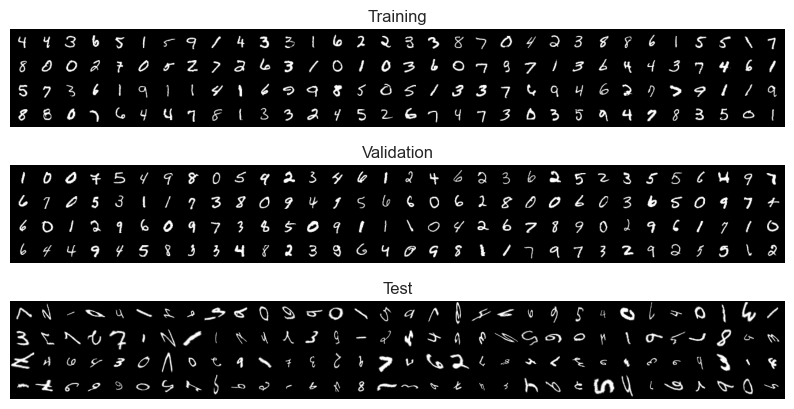

In [11]:
#test images
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 5))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(test_loader_transformed))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Validation')
axs[2].set_title('Test')

for ax in axs.flat:
    ax.axis('off')

In [12]:
from experiment_thesis.main import train_and_get_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model

In [13]:
model_dir_path = os.path.join(current_path, "experiment_files", "models")
embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")
# Add results dir and helper for save paths
results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture,"different_domain_cd")
os.makedirs(results_dir_path, exist_ok=True)
def savepath(label: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(results_dir_path, f"{safe}.json")


In [14]:
from utils.augments import small_affine_augment_2d
from utils.sampling_strategy import TransformLatentSamplingStrategy
from utils.sampling import BatchNegativeSampler
batch_transform = BatchNegativeSampler(
    None,
    transform_true_function=small_affine_augment_2d,number_of_negatives=0,
).eval().cuda()

In [15]:
model = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train= f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": 100,
        "precision": "16-mixed",
},load_if_exists=True)


res = evaluate_base_model(model, test_loader_transformed, device)
print(res)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small.safetensors


{'accuracy': 0.37689998745918274, 'f2_macro': 0.37094762921333313, 'f2_micro': 0.37689998745918274, 'f2_weighted': 0.3730011582374573}


In [16]:
dataset_info

Box({'input_size': (1, 40, 40), 'num_classes': 10, 'transform_seq_name': 'biggermnist_default', 'datatype': 'image', 'name': 'bigger_mnist', 'resample_method': 'grid_resample', 'pad': 6, 'epochs': 100, 'batch_size': 128, 'batch_size_search': 1024})

In [17]:
from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images
if dataset_info.transform_seq_name is not None and dataset_info.datatype == "image":
    transform_seq = get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
                resample_method=dataset_info.resample_method
    )

In [18]:
transform_seq.cuda()

TransformSequence()

In [19]:
print(list(model.named_modules()))

[('', FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2):

In [20]:
from torch.utils.data import SequentialSampler
from embedding_cache import LayerEmbeddingCache
transform_name = dataset_info.transform_seq_name

cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train"

cache_train = LayerEmbeddingCache(model,train_loader_no_shuffle,cache_dir=os.path.join(embedding_cache_path,cache_name_train))
embeddings_t,final_t,classes_t = cache_train("fc",capture_modes='input',flatten=True)

In [21]:
dual_output_model = cache_train.make_wrapper("fc",capture_modes='input',concat=False,flatten=True)


In [22]:
inter,final = dual_output_model(torch.randn(2,1,28,28).to(device))

In [23]:
from utils.eval.ood_performance import evaluate_confidence_module
# Add cached runner
from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search
import json, math, pandas as pd



In [24]:
from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence, PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence,PerClassKNNConfidence

from confidence.input_transform import InputTransformImage,PCAInputModule,RandomProjectionModule
input_transform_image = InputTransformImage((3,3),(128,7,7))
input_transform_pca = PCAInputModule(512)
input_transform_random = RandomProjectionModule(512,method="gaussian")


nn_pytorch_pretrained = PerClassKNNConfidence(metric="cosine",input_transform=None)
nn_pytorch_pretrained.fit(embeddings_t,classes_t)
nn_pytorch_pretrained.cuda()

conf_split_pretrained = PredictedSplitConfidence(nn_pytorch_pretrained,EnergyConfidence(), mult=False,b=0.0)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model,conf_split_pretrained,index=1)
problem_nn_pytorch_pretrained = TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_seq,consolidate_method="consolidate_simple")


In [25]:
from search import shgo,tree
cd_4 = tree.WeightedCoordinateDescent(samples_per_dim=[15,15,15,15])
cd_5 = tree.WeightedCoordinateDescent(samples_per_dim=[15,12,11,11,11])
cd_6 = tree.WeightedCoordinateDescent(samples_per_dim=[15,9,9,9,9,9])
model.cuda().eval()

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [26]:
from utils.transform_sequence import TransformSequence
from utils.affine_transforms import AffineTransformation2D

transformation_direct =[AffineTransformation2D.DIRECT.value]
transform_seq_direct = TransformSequence(
    transformations=transformation_direct,
    domains=[((-1.2,1.2),(-1.2,1.2),(-1.2,1.2),(-1.2,1.2),(-0.01,0.01),(-0.01,0.01),)],
    device=device,
    dtype=torch.float32,
    reflect=False,
)

In [27]:
repeats =4
overwrite = False

In [28]:


load_or_run_evaluate_confidence_and_search(
    model, optimizer=cd_5, problem=problem_nn_pytorch_pretrained,
    test_loader=test_loader_transformed, max_batch_override=1280,
    repeats=repeats, overwrite=overwrite, save_path=savepath("random_search_knn_default")
)

{'repeats': 4,
 'accuracy_mean': 0.7235749959945679,
 'accuracy_std': 0.002095016185194254,
 'accuracy_se': 0.001047508092597127,
 'f2_macro_mean': 0.7186445593833923,
 'f2_macro_std': 0.0023427866399288177,
 'f2_macro_se': 0.0011713933199644089,
 'f2_micro_mean': 0.7235749959945679,
 'f2_micro_std': 0.002095016185194254,
 'f2_micro_se': 0.001047508092597127,
 'f2_weighted_mean': 0.7216295003890991,
 'f2_weighted_std': 0.002234450075775385,
 'f2_weighted_se': 0.0011172250378876925,
 'per_run': [{'accuracy': 0.7225000262260437,
   'f2_macro': 0.7173478603363037,
   'f2_micro': 0.7225000262260437,
   'f2_weighted': 0.7205126881599426,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.7261999845504761,
   'f2_macro': 0.7214651107788086,
   'f2_micro': 0.7261999845504761,
   'f2_weighted': 0.7243578433990479,
   'per_sample_errors': None,
   'per_sample_matrice

In [29]:
problem_nn_pytorch_pretrained_direct = TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_seq_direct,consolidate_method="consolidate_simple")



load_or_run_evaluate_confidence_and_search(
    model, optimizer=cd_6, problem=problem_nn_pytorch_pretrained_direct,
    test_loader=test_loader_transformed, max_batch_override=1280,
    repeats=repeats, overwrite=overwrite, save_path=savepath("random_search_knn_matrix")
)

{'repeats': 4,
 'accuracy_mean': 0.3796749711036682,
 'accuracy_std': 0.0010045694652944803,
 'accuracy_se': 0.0005022847326472402,
 'f2_macro_mean': 0.36429673433303833,
 'f2_macro_std': 0.0008650646777823567,
 'f2_macro_se': 0.00043253233889117837,
 'f2_micro_mean': 0.3796749711036682,
 'f2_micro_std': 0.0010045694652944803,
 'f2_micro_se': 0.0005022847326472402,
 'f2_weighted_mean': 0.36815235018730164,
 'f2_weighted_std': 0.0008317173342220485,
 'f2_weighted_se': 0.00041585866711102426,
 'per_run': [{'accuracy': 0.37959998846054077,
   'f2_macro': 0.36460357904434204,
   'f2_micro': 0.37959998846054077,
   'f2_weighted': 0.36832159757614136,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.37880000472068787,
   'f2_macro': 0.36360740661621094,
   'f2_micro': 0.37880000472068787,
   'f2_weighted': 0.3673957884311676,
   'per_sample_errors': None,
   'pe

In [30]:
import torch
import matplotlib.pyplot as plt
from utils.eval.ood_performance import ITSWRAPPER

def prepare_img_for_plot(img):
    """
    Convert tensor to numpy array suitable for imshow.
    Clips/normalizes values to [0,1].
    """
    img = img.detach().cpu()

    if img.dim() == 3 and img.shape[0] in [1, 3]:
        img = img.permute(1, 2, 0)  # C,H,W -> H,W,C

    img = img.numpy()

    # Normalize if not in [0,1]
    min_val, max_val = img.min(), img.max()
    #clip
    img = np.clip(img, 0, 1)
    return img


def plot_transformed_batch(data_loader, problem, optimizer, k=8, device=None):
    """
    Fetches the first batch, applies transformation, and plots the first k samples.
    """
    with torch.no_grad():
        if device is None:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        data_iter = iter(data_loader)
        data, _ = next(data_iter)
        data = data[:k].to(device)

        # Optimize / transform
        if not isinstance(optimizer, ITSWRAPPER):
            res = optimizer.optimize(problem, data, y=None)
            print(res[1].detach().cpu().numpy()[:k])
            x_trans = problem.transform(data, res[0])
            conf = problem.confidence_module(x_trans, None)[0]
            print(conf.detach().cpu().numpy()[:k])
        else:
            x_trans, _ = optimizer.optimize(problem, data)

        x_trans = x_trans.detach().cpu()
        data = data.detach().cpu()

        # --- Plot original ---
        plt.figure(figsize=(k * 2, 2))
        for i in range(min(k, data.shape[0])):
            plt.subplot(1, k, i + 1)
            img = prepare_img_for_plot(data[i])
            if img.ndim == 2 or img.shape[-1] == 1:
                plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
            else:
                plt.imshow(img)
            plt.axis('off')
        plt.tight_layout()
        plt.show()

        # --- Plot transformed ---
        plt.figure(figsize=(k * 2, 2))
        for i in range(min(k, x_trans.shape[0])):
            plt.subplot(1, k, i + 1)
            img = prepare_img_for_plot(x_trans[i])
            if img.ndim == 2 or img.shape[-1] == 1:
                plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
            else:
                plt.imshow(img)
            plt.axis('off')
        plt.tight_layout()
        plt.show()


In [31]:
model.eval()

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [32]:
problem_nn_pytorch_pretrained_direct.max_batch_size=1280

In [33]:
import gc
gc.collect()
torch.cuda.empty_cache()

[-0.96533203 -0.9614258  -0.98535156 -0.9560547  -0.99609375 -0.97509766
 -0.96435547 -0.9941406 ]
[0.96533203 0.9604492  0.98535156 0.9560547  0.99609375 0.9760742
 0.96435547 0.9941406 ]


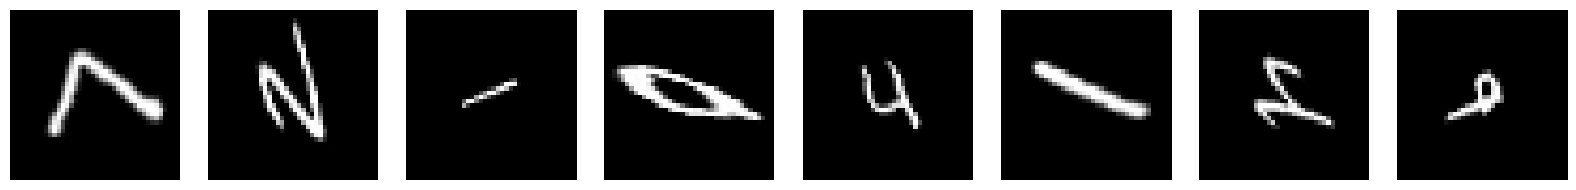

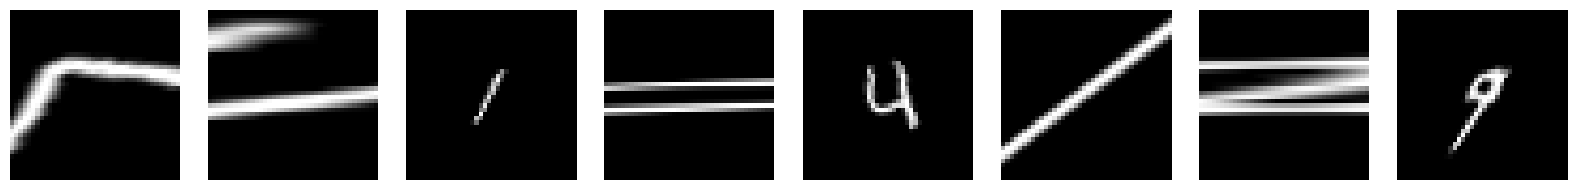

In [34]:
plot_transformed_batch(test_loader_transformed, problem_nn_pytorch_pretrained_direct, cd_6, k=8, device=device)

In [35]:
problem_nn_pytorch_pretrained.max_batch_size =1280

[-0.99609375 -0.99609375 -0.9980469  -0.9873047  -0.9980469  -0.9970703
 -0.9902344  -0.9921875 ]
[0.99609375 0.99609375 0.9980469  0.9873047  0.9980469  0.9970703
 0.9902344  0.9921875 ]


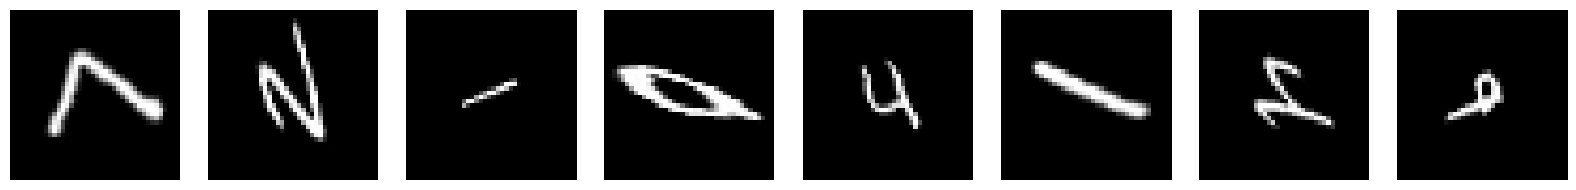

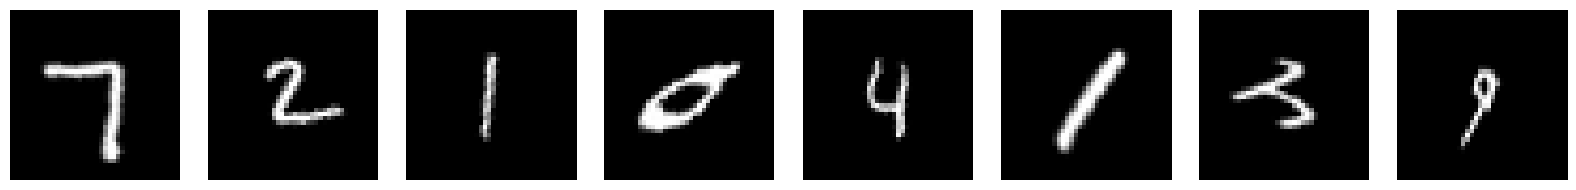

In [36]:
plot_transformed_batch(test_loader_transformed, problem_nn_pytorch_pretrained, cd_5, k=8, device=device)


[-0.99609375 -0.9941406  -0.99902344 -0.99609375 -0.9970703  -0.9951172
 -0.98291016 -0.99902344]
[0.99609375 0.9941406  0.99902344 0.99609375 0.9970703  0.9951172
 0.98291016 0.99902344]


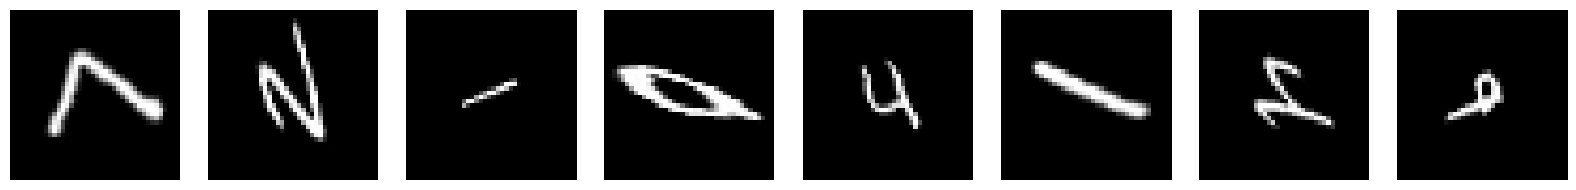

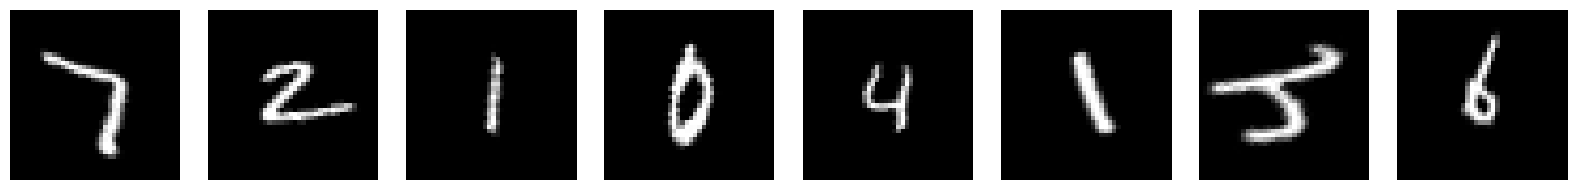

{'repeats': 4,
 'accuracy_mean': 0.6303499937057495,
 'accuracy_std': 0.0013527593109756708,
 'accuracy_se': 0.0006763796554878354,
 'f2_macro_mean': 0.6236529350280762,
 'f2_macro_std': 0.0013793717371299863,
 'f2_macro_se': 0.0006896858685649931,
 'f2_micro_mean': 0.6303499937057495,
 'f2_micro_std': 0.0013527593109756708,
 'f2_micro_se': 0.0006763796554878354,
 'f2_weighted_mean': 0.6272265315055847,
 'f2_weighted_std': 0.001387125812470913,
 'f2_weighted_se': 0.0006935629062354565,
 'per_run': [{'accuracy': 0.6313999891281128,
   'f2_macro': 0.624972403049469,
   'f2_micro': 0.6313999891281128,
   'f2_weighted': 0.62845379114151,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.6305000185966492,
   'f2_macro': 0.623453676700592,
   'f2_micro': 0.6305000185966492,
   'f2_weighted': 0.627178966999054,
   'per_sample_errors': None,
   'per_sample_matrices

In [37]:
import torch

# 1) Replace angle rotation with complex rotation; keep shears and scales unchanged
transformations_rot_complex = [
    AffineTransformation2D.ROTATION_COMPLEX.value,
    AffineTransformation2D.SHEARING_X.value,
    AffineTransformation2D.SHEARING_Y.value,
    AffineTransformation2D.SCALING_X.value,
    AffineTransformation2D.SCALING_Y.value,
]
domains_rot_complex = [
    (-torch.pi, torch.pi),                    # complex rotation angle-like param
    ((-0.5, 0.5),),                           # shear x
    ((-0.5, 0.5),),                           # shear y
    ((1 / 1.8 - 1, 0.8),),                    # scale x delta
    ((1 / 1.8 - 1, 0.8),),                    # scale y delta
]
transform_seq_rot_complex = TransformSequence(
    transformations=transformations_rot_complex,
    domains=domains_rot_complex,
    device=device,
    dtype=torch.float32,
    reflect=False,
)
problem_rot_complex = TransformationProblem(
    conf_mod_nn_pytorch_pretrained, transform_seq_rot_complex,
    consolidate_method="consolidate_simple", max_batch_size=1280
)
plot_transformed_batch(test_loader_transformed, problem_rot_complex, cd_6, k=8, device=device)


# Complex rotation (cached)
load_or_run_evaluate_confidence_and_search(
    model, optimizer=cd_6, problem=problem_rot_complex,
    test_loader=test_loader_transformed, max_batch_override=1280,
    repeats=repeats, overwrite=overwrite, save_path=savepath("random_search_knn_rot_complex")
)

[-0.9667969 -0.9941406 -0.9970703 -0.9941406 -0.9980469 -0.9980469
 -0.9921875 -0.9970703]
[0.9667969  0.9941406  0.9970703  0.99316406 0.9980469  0.9980469
 0.9921875  0.9970703 ]


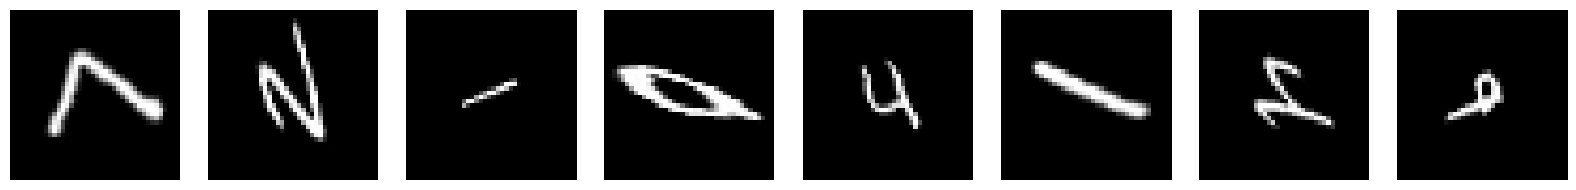

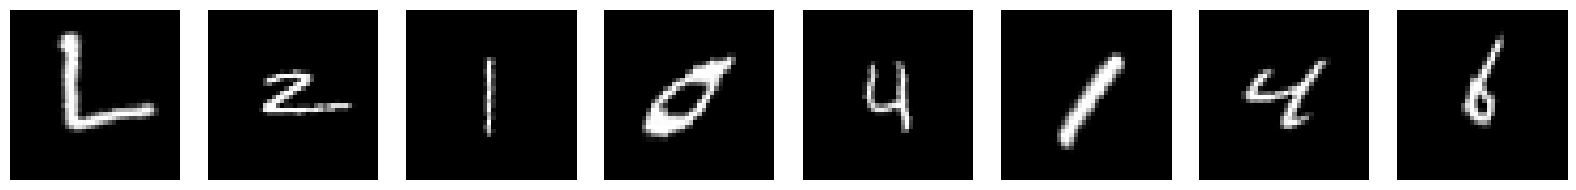

{'repeats': 4,
 'accuracy_mean': 0.7226250171661377,
 'accuracy_std': 0.0032438295893371105,
 'accuracy_se': 0.0016219147946685553,
 'f2_macro_mean': 0.7174801230430603,
 'f2_macro_std': 0.003500192891806364,
 'f2_macro_se': 0.001750096445903182,
 'f2_micro_mean': 0.7226250171661377,
 'f2_micro_std': 0.0032438295893371105,
 'f2_micro_se': 0.0016219147946685553,
 'f2_weighted_mean': 0.7204887270927429,
 'f2_weighted_std': 0.003404037095606327,
 'f2_weighted_se': 0.0017020185478031635,
 'per_run': [{'accuracy': 0.7251999974250793,
   'f2_macro': 0.7200312614440918,
   'f2_micro': 0.7251999974250793,
   'f2_weighted': 0.7230958938598633,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.7182000279426575,
   'f2_macro': 0.7126179337501526,
   'f2_micro': 0.7182000279426575,
   'f2_weighted': 0.7157958149909973,
   'per_sample_errors': None,
   'per_sample_matri

In [38]:



# 2) Replace angle rotation with skew rotation; keep shears and scales unchanged
transformations_rot_skew = [
    AffineTransformation2D.ROTATION_SKEW.value,
    AffineTransformation2D.SHEARING_X.value,
    AffineTransformation2D.SHEARING_Y.value,
    AffineTransformation2D.SCALING_X.value,
    AffineTransformation2D.SCALING_Y.value,
]
domains_rot_skew = [
    (-torch.pi, torch.pi),                    # skew rotation angle-like param
    ((-0.5, 0.5),),                           # shear x
    ((-0.5, 0.5),),                           # shear y
    ((1 / 1.8 - 1, 0.8),),                    # scale x delta
    ((1 / 1.8 - 1, 0.8),),                    # scale y delta
]
transform_seq_rot_skew = TransformSequence(
    transformations=transformations_rot_skew,
    domains=domains_rot_skew,
    device=device,
    dtype=torch.float32,
    reflect=False,
)
problem_rot_skew = TransformationProblem(
    conf_mod_nn_pytorch_pretrained, transform_seq_rot_skew,
    consolidate_method="consolidate_simple", max_batch_size=1280
)
plot_transformed_batch(test_loader_transformed, problem_rot_skew, cd_5, k=8, device=device)


# Skew rotation (cached)
load_or_run_evaluate_confidence_and_search(
    model, optimizer=cd_5, problem=problem_rot_skew,
    test_loader=test_loader_transformed, max_batch_override=1280,
    repeats=repeats, overwrite=overwrite, save_path=savepath("random_search_knn_rot_skew")
)

[-0.9902344 -0.9941406 -1.        -0.9951172 -0.9980469 -1.
 -0.9941406 -0.9892578]
[0.9902344  0.99316406 1.         0.9951172  0.9980469  1.
 0.9941406  0.9892578 ]


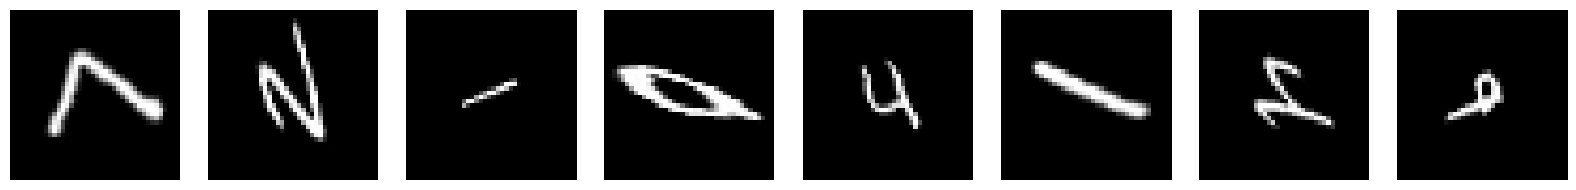

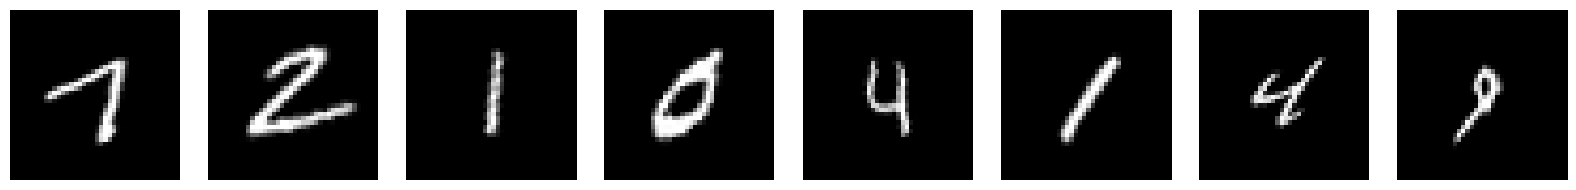

{'repeats': 4,
 'accuracy_mean': 0.729075014591217,
 'accuracy_std': 0.0021884047891944647,
 'accuracy_se': 0.0010942023945972323,
 'f2_macro_mean': 0.7239165902137756,
 'f2_macro_std': 0.0023578114341944456,
 'f2_macro_se': 0.0011789057170972228,
 'f2_micro_mean': 0.729075014591217,
 'f2_micro_std': 0.0021884047891944647,
 'f2_micro_se': 0.0010942023945972323,
 'f2_weighted_mean': 0.7266993522644043,
 'f2_weighted_std': 0.002310358453541994,
 'f2_weighted_se': 0.001155179226770997,
 'per_run': [{'accuracy': 0.7275000214576721,
   'f2_macro': 0.7221840620040894,
   'f2_micro': 0.7275000214576721,
   'f2_weighted': 0.7251066565513611,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.7285000085830688,
   'f2_macro': 0.7234103679656982,
   'f2_micro': 0.7285000085830688,
   'f2_weighted': 0.7260935306549072,
   'per_sample_errors': None,
   'per_sample_matric

In [39]:

# 3) Replace shear x+y and scale x+y with a single SHEARSCALE; keep angle rotation
transformations_shearscale = [
    AffineTransformation2D.ROTATION.value,
    AffineTransformation2D.SHEARSCALE.value,
]
domains_shearscale = [
    (-torch.pi, torch.pi),                    # angle rotation
    (
        (1 / 1.8 - 1, 0.8),                   # scale x delta
        (1 / 1.8 - 1, 0.8),                   # scale y delta
        (-0.5, 0.5),                          # shear x
    ),
]
transform_seq_shearscale = TransformSequence(
    transformations=transformations_shearscale,
    domains=domains_shearscale,
    device=device,
    dtype=torch.float32,
    reflect=False,
)
problem_shearscale = TransformationProblem(
    conf_mod_nn_pytorch_pretrained, transform_seq_shearscale,
    consolidate_method="consolidate_simple", max_batch_size=1280
)
plot_transformed_batch(test_loader_transformed, problem_shearscale, cd_4, k=8, device=device)


# ShearScale (cached)
load_or_run_evaluate_confidence_and_search(
    model, optimizer=cd_4, problem=problem_shearscale,
    test_loader=test_loader_transformed, max_batch_override=1280,
    repeats=repeats, overwrite=overwrite, save_path=savepath("random_search_knn_shearscale")
)

[-0.9970703  -0.97509766 -0.9970703  -0.9970703  -0.9980469  -0.9970703
 -0.9902344  -0.99609375]
[0.9970703  0.97509766 0.9970703  0.9970703  0.9980469  0.9970703
 0.9902344  0.99609375]


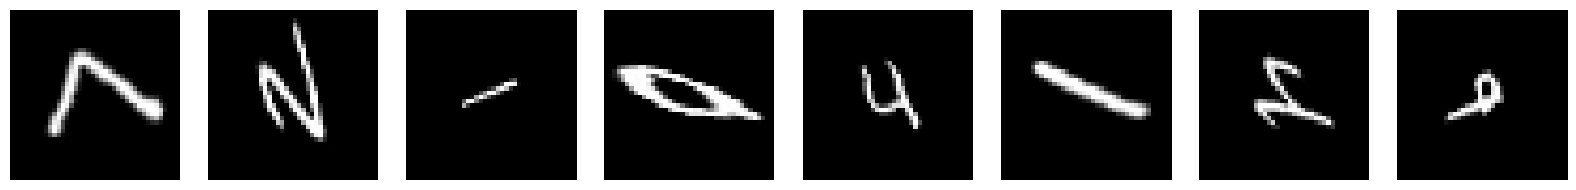

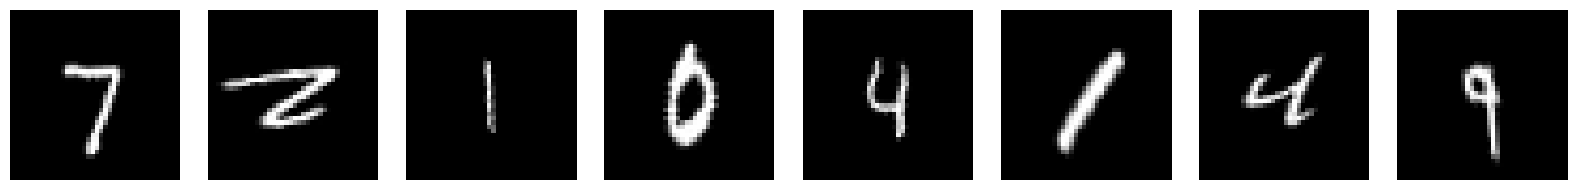

{'repeats': 4,
 'accuracy_mean': 0.7242749929428101,
 'accuracy_std': 0.0016938827466219664,
 'accuracy_se': 0.0008469413733109832,
 'f2_macro_mean': 0.7192587852478027,
 'f2_macro_std': 0.0017713501583784819,
 'f2_macro_se': 0.0008856750791892409,
 'f2_micro_mean': 0.7242749929428101,
 'f2_micro_std': 0.0016938827466219664,
 'f2_micro_se': 0.0008469413733109832,
 'f2_weighted_mean': 0.722328245639801,
 'f2_weighted_std': 0.0018102893372997642,
 'f2_weighted_se': 0.0009051446686498821,
 'per_run': [{'accuracy': 0.7232999801635742,
   'f2_macro': 0.7181356549263,
   'f2_micro': 0.7232999801635742,
   'f2_weighted': 0.7211588621139526,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.7236999869346619,
   'f2_macro': 0.7187504768371582,
   'f2_micro': 0.7236999869346619,
   'f2_weighted': 0.7219480872154236,
   'per_sample_errors': None,
   'per_sample_matric

In [40]:

# 4) Add translation together with SHEARSCALE; keep angle rotation
transformations_trans_shearscale = [
    AffineTransformation2D.ROTATION.value,
    AffineTransformation2D.SHEARING.value,
    AffineTransformation2D.SCALING_X.value,
    AffineTransformation2D.SCALING_Y.value,
    #AffineTransformation2D.TRANSLATION.value,
]
domains_trans_shearscale = [
            (-torch.pi, torch.pi),
            ((-0.5, 0.5),),
            ((1/(1+0.8)-1, 0.8),),
            ((1/(1+0.8)-1, 0.8),)
        ]
transform_seq_trans_shearscale = TransformSequence(
    transformations=transformations_trans_shearscale,
    domains=domains_trans_shearscale,
    device=device,
    dtype=torch.float32,
    reflect=False,
)
problem_trans_shearscale = TransformationProblem(
    conf_mod_nn_pytorch_pretrained, transform_seq_trans_shearscale,
    consolidate_method="consolidate_simple", max_batch_size=1280
)
plot_transformed_batch(test_loader_transformed, problem_trans_shearscale, cd_5, k=8, device=device)


load_or_run_evaluate_confidence_and_search(
    model, optimizer=cd_5, problem=problem_trans_shearscale,
    test_loader=test_loader_transformed, max_batch_override=1280,
    repeats=repeats, overwrite=overwrite, save_path=savepath("random_search_knn_shearxy")
)



[-0.9970703  -0.9941406  -0.99902344 -0.9838867  -0.99609375 -0.9980469
 -0.9863281  -0.99609375]
[0.9970703  0.9941406  0.9980469  0.9838867  0.99609375 0.9980469
 0.9863281  0.99609375]


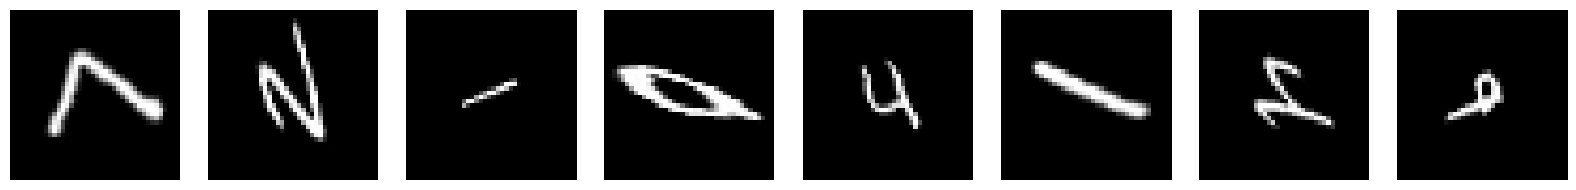

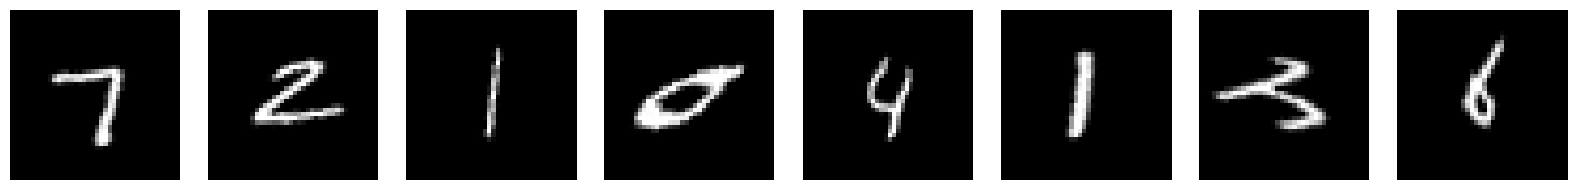

{'repeats': 4,
 'accuracy_mean': 0.7224249839782715,
 'accuracy_std': 0.00199561077170074,
 'accuracy_se': 0.00099780538585037,
 'f2_macro_mean': 0.7173697352409363,
 'f2_macro_std': 0.0019613918848335743,
 'f2_macro_se': 0.0009806959424167871,
 'f2_micro_mean': 0.7224249839782715,
 'f2_micro_std': 0.00199561077170074,
 'f2_micro_se': 0.00099780538585037,
 'f2_weighted_mean': 0.7204117178916931,
 'f2_weighted_std': 0.0019526284886524081,
 'f2_weighted_se': 0.0009763142443262041,
 'per_run': [{'accuracy': 0.7240999937057495,
   'f2_macro': 0.7190577387809753,
   'f2_micro': 0.7240999937057495,
   'f2_weighted': 0.7222536206245422,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.7235000133514404,
   'f2_macro': 0.7183194160461426,
   'f2_micro': 0.7235000133514404,
   'f2_weighted': 0.7212687730789185,
   'per_sample_errors': None,
   'per_sample_matrices':

In [41]:

# 4) Add translation together with SHEARSCALE; keep angle rotation
transformations_trans_shearscale = [
    AffineTransformation2D.ROTATION.value,
    AffineTransformation2D.SHEARING_X.value,
    AffineTransformation2D.SCALING_X.value,
    AffineTransformation2D.SCALING_Y.value,
]
domains_trans_shearscale = [
            (-torch.pi, torch.pi),
            ((-0.5, 0.5),),
            ((1/(1+0.8)-1, 0.8),),
            ((1/(1+0.8)-1, 0.8),)
        ]
transform_seq_trans_shearscale = TransformSequence(
    transformations=transformations_trans_shearscale,
    domains=domains_trans_shearscale,
    device=device,
    dtype=torch.float32,
    reflect=False,
)
problem_trans_shearscale = TransformationProblem(
    conf_mod_nn_pytorch_pretrained, transform_seq_trans_shearscale,
    consolidate_method="consolidate_simple", max_batch_size=1280
)
plot_transformed_batch(test_loader_transformed, problem_trans_shearscale, cd_4, k=8, device=device)


load_or_run_evaluate_confidence_and_search(
    model, optimizer=cd_4, problem=problem_trans_shearscale,
    test_loader=test_loader_transformed, max_batch_override=1280,
    repeats=repeats, overwrite=overwrite, save_path=savepath("random_search_knn_shear_x")
)



[-0.99609375 -0.9873047  -0.9980469  -0.99316406 -0.9980469  -0.9980469
 -0.99316406 -0.9970703 ]
[0.99609375 0.9873047  0.9980469  0.99316406 0.9980469  0.9980469
 0.99316406 0.9970703 ]


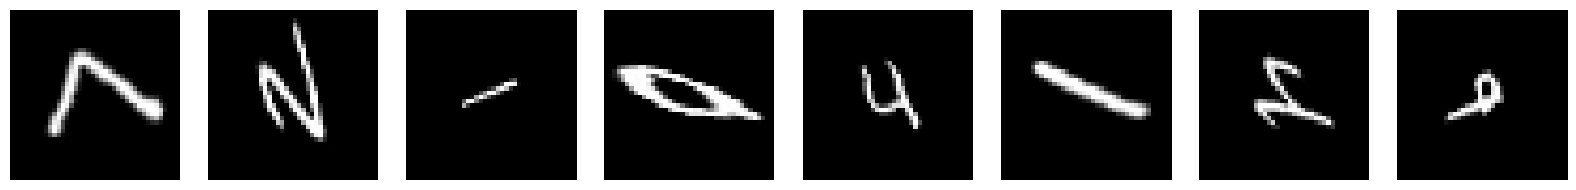

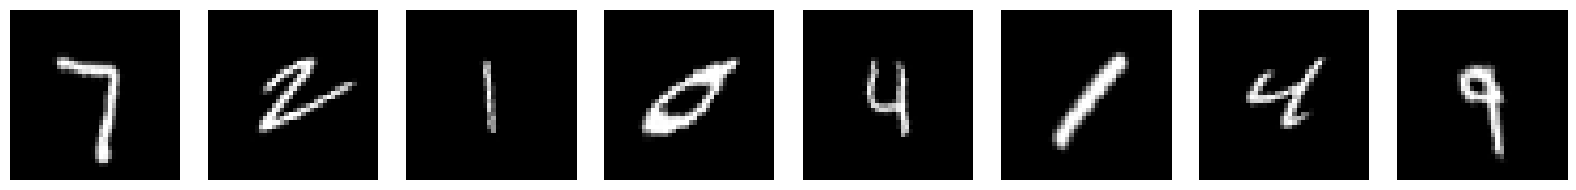

{'repeats': 4,
 'accuracy_mean': 0.7214249968528748,
 'accuracy_std': 0.0048753502778708935,
 'accuracy_se': 0.0024376751389354467,
 'f2_macro_mean': 0.7163271903991699,
 'f2_macro_std': 0.004980136174708605,
 'f2_macro_se': 0.0024900680873543024,
 'f2_micro_mean': 0.7214249968528748,
 'f2_micro_std': 0.0048753502778708935,
 'f2_micro_se': 0.0024376751389354467,
 'f2_weighted_mean': 0.7194565534591675,
 'f2_weighted_std': 0.004856643732637167,
 'f2_weighted_se': 0.0024283218663185835,
 'per_run': [{'accuracy': 0.7249000072479248,
   'f2_macro': 0.7199509143829346,
   'f2_micro': 0.7249000072479248,
   'f2_weighted': 0.7230136394500732,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.714900016784668,
   'f2_macro': 0.7097206115722656,
   'f2_micro': 0.714900016784668,
   'f2_weighted': 0.7130540609359741,
   'per_sample_errors': None,
   'per_sample_matric

In [42]:
cd_7 = tree.WeightedCoordinateDescent(samples_per_dim=[15,8,8,8,7,7,7])
# 4) Add translation together with SHEARSCALE; keep angle rotation
transformations_trans_shearscale = [
    AffineTransformation2D.ROTATION.value,
    AffineTransformation2D.SHEARING.value,
    AffineTransformation2D.SCALING_X.value,
    AffineTransformation2D.SCALING_Y.value,
    AffineTransformation2D.TRANSLATION.value,
]
domains_trans_shearscale = [
    (-torch.pi, torch.pi),                    # angle rotation
    ((-0.5, 0.5),),                           # shear x
    ((1 / 1.8 - 1, 0.8),),                    # scale x delta
    ((1 / 1.8 - 1, 0.8),),                    # scale y delta
    ((-0.1, 0.1), (-0.1, 0.1)),           # translation x,y
]
transform_seq_trans_shearscale = TransformSequence(
    transformations=transformations_trans_shearscale,
    domains=domains_trans_shearscale,
    device=device,
    dtype=torch.float32,
    reflect=False,
)
problem_trans_shearscale = TransformationProblem(
    conf_mod_nn_pytorch_pretrained, transform_seq_trans_shearscale,
    consolidate_method="consolidate_simple", max_batch_size=1280
)
plot_transformed_batch(test_loader_transformed, problem_trans_shearscale, cd_7, k=8, device=device)

load_or_run_evaluate_confidence_and_search(
    model, optimizer=cd_7,
    problem=problem_trans_shearscale,
    test_loader=test_loader_transformed, max_batch_override=1280,
    repeats=repeats, overwrite=overwrite, save_path=savepath("random_search_knn_translation"))


In [43]:
#ow test different ways to scale the image
from utils.transforms.apply import grid_resample,grid_resample_bicubic,grid_resample_nearest,grid_resample_blur_simple,grid_resample_border,grid_resample_blur,grid_resample_reflection,grid_resample_deblur

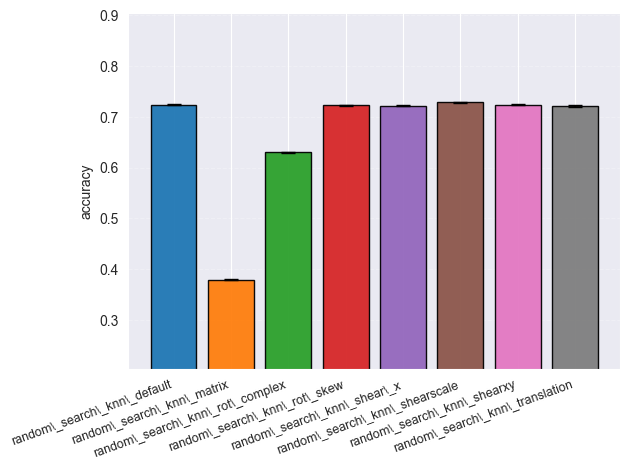


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\resnet_small\different_domain_cd\resnet_small_all_results_summary.tex`

\begin{table}
\caption{resnet_small All results (mean ± SE)}
\label{tab:resnet_small_all_results}
\begin{tabular}{lllllllll}
\toprule
 & random\_search\_knn\_default & random\_search\_knn\_matrix & random\_search\_knn\_rot\_complex & random\_search\_knn\_rot\_skew & random\_search\_knn\_shear\_x & random\_search\_knn\_shearscale & random\_search\_knn\_shearxy & random\_search\_knn\_translation \\
Metric &  &  &  &  &  &  &  &  \\
\midrule
accuracy & 0.7236 ± 0.0010 & 0.3797 ± 0.0005 & 0.6304 ± 0.0007 & 0.7226 ± 0.0016 & 0.7224 ± 0.0010 & 0.7291 ± 0.0011 & 0.7243 ± 0.0008 & 0.7214 ± 0.0024 \\
f2\_macro & 0.7186 ± 0.0012 & 0.3643 ± 0.0004 & 0.6237 ± 0.0007 & 0.7175 ± 0.0018 & 0.7174 ± 0.0010 & 0.7239 ± 0.0012 & 0.7193 ± 0.0009 & 0.7163 ± 0.0025 \\
f2\_micro & 0.7236 ± 0.0010 & 0.3797 ± 0.0005 & 0.6304 ± 0.0

In [44]:
import os
from utils.eval.vis import process_and_plot_groups

# `results_dir_path` and `architecture` are already defined in the notebook;
# `results_dir_path` should point to the directory containing the .json result files
json_files = sorted([f for f in os.listdir(results_dir_path) if f.endswith(".json")])
if not json_files:
    print(f"No .json result files found in `{results_dir_path}`")
else:
    items = [(os.path.splitext(f)[0], f) for f in json_files]
    groups = [("all_results", "All results", items)]
    process_and_plot_groups(groups, results_dir_path, architecture)

In [45]:
json_files

['random_search_knn_default.json',
 'random_search_knn_matrix.json',
 'random_search_knn_rot_complex.json',
 'random_search_knn_rot_skew.json',
 'random_search_knn_shear_x.json',
 'random_search_knn_shearscale.json',
 'random_search_knn_shearxy.json',
 'random_search_knn_translation.json']

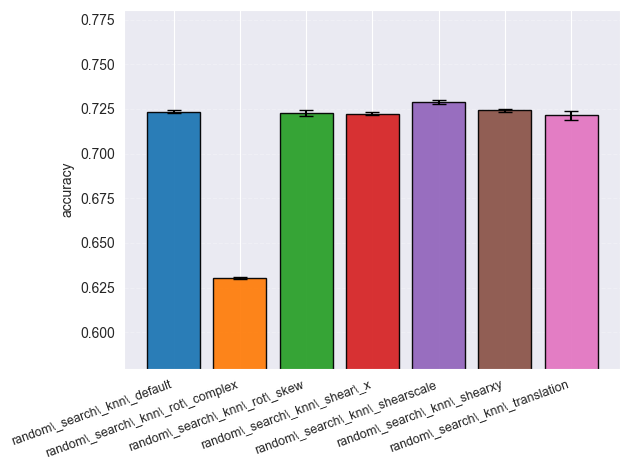


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\resnet_small\different_domain_cd\resnet_small_all_results_summary.tex`

\begin{table}
\caption{resnet_small All results (mean ± SE)}
\label{tab:resnet_small_all_results}
\begin{tabular}{llllllll}
\toprule
 & random\_search\_knn\_default & random\_search\_knn\_rot\_complex & random\_search\_knn\_rot\_skew & random\_search\_knn\_shear\_x & random\_search\_knn\_shearscale & random\_search\_knn\_shearxy & random\_search\_knn\_translation \\
Metric &  &  &  &  &  &  &  \\
\midrule
accuracy & 0.7236 ± 0.0010 & 0.6304 ± 0.0007 & 0.7226 ± 0.0016 & 0.7224 ± 0.0010 & 0.7291 ± 0.0011 & 0.7243 ± 0.0008 & 0.7214 ± 0.0024 \\
f2\_macro & 0.7186 ± 0.0012 & 0.6237 ± 0.0007 & 0.7175 ± 0.0018 & 0.7174 ± 0.0010 & 0.7239 ± 0.0012 & 0.7193 ± 0.0009 & 0.7163 ± 0.0025 \\
f2\_micro & 0.7236 ± 0.0010 & 0.6304 ± 0.0007 & 0.7226 ± 0.0016 & 0.7224 ± 0.0010 & 0.7291 ± 0.0011 & 0.7243 ± 0.0008 & 0.7214 ± 0

In [46]:
import os
from utils.eval.vis import process_and_plot_groups

# `results_dir_path` and `architecture` are already defined in the notebook;
# `results_dir_path` should point to the directory containing the .json result files
json_files = sorted([f for f in os.listdir(results_dir_path) if f.endswith(".json")])
#remove matrix one random_search_knn_matrix.json
json_files = [f for f in json_files if f != "random_search_knn_matrix.json"]

if not json_files:
    print(f"No .json result files found in `{results_dir_path}`")
else:
    items = [(os.path.splitext(f)[0], f) for f in json_files]
    groups = [("all_results", "All results", items)]
    process_and_plot_groups(groups, results_dir_path, architecture)

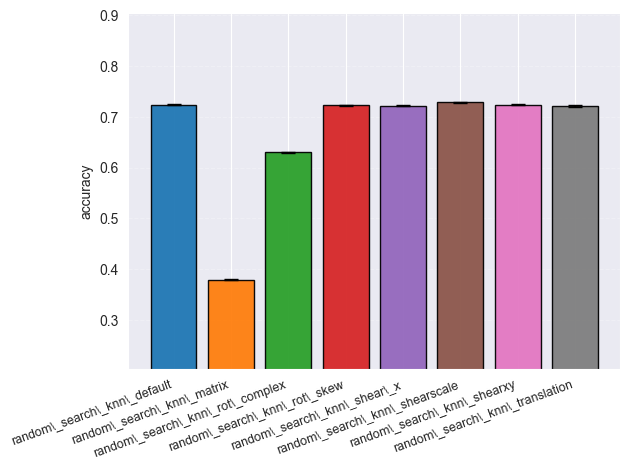


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\resnet_small\different_domain_cd\resnet_small_all_results_summary.tex`

\begin{table}
\caption{resnet_small All results (mean ± SE)}
\label{tab:resnet_small_all_results}
\begin{tabular}{lllllllll}
\toprule
 & random\_search\_knn\_default & random\_search\_knn\_matrix & random\_search\_knn\_rot\_complex & random\_search\_knn\_rot\_skew & random\_search\_knn\_shear\_x & random\_search\_knn\_shearscale & random\_search\_knn\_shearxy & random\_search\_knn\_translation \\
Metric &  &  &  &  &  &  &  &  \\
\midrule
accuracy & 0.7236 ± 0.0010 & 0.3797 ± 0.0005 & 0.6304 ± 0.0007 & 0.7226 ± 0.0016 & 0.7224 ± 0.0010 & 0.7291 ± 0.0011 & 0.7243 ± 0.0008 & 0.7214 ± 0.0024 \\
f2\_macro & 0.7186 ± 0.0012 & 0.3643 ± 0.0004 & 0.6237 ± 0.0007 & 0.7175 ± 0.0018 & 0.7174 ± 0.0010 & 0.7239 ± 0.0012 & 0.7193 ± 0.0009 & 0.7163 ± 0.0025 \\
f2\_micro & 0.7236 ± 0.0010 & 0.3797 ± 0.0005 & 0.6304 ± 0.0

In [47]:
# python
# Ensure inline backend (run once at top of notebook)
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline")

# Call processing but do not save PGF (this will call plt.show() inside plot_group_short)
from utils.eval.vis import process_and_plot_groups

json_files = sorted([f for f in os.listdir(results_dir_path) if f.endswith(".json")])
if not json_files:
    print(f"No .json result files found in `{results_dir_path}`")
else:
    items = [(os.path.splitext(f)[0], f) for f in json_files]
    groups = [("all_results", "All results", items)]
    process_and_plot_groups(groups, results_dir_path, architecture, save_pgf=False)

In [48]:
transform_seq_normal = get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
    ).cuda()

In [49]:
transform_seq_normal.domains

[(-3.141592653589793, 3.141592653589793),
 ((-0.5, 0.5),),
 ((-0.5, 0.5),),
 ((-0.4444444444444444, 0.8),),
 ((-0.4444444444444444, 0.8),)]

In [50]:
#todo maybe test in another file what settings make sense

In [51]:
transform_seq_normal.init_method = "individual"
transform_seq_normal.init_method = "latin_hypercube"

In [52]:
figure_path = os.path.join(current_path, "experiment_files", "export", "fig", "a_different_domain_cd", dataset,
                           transform_name)

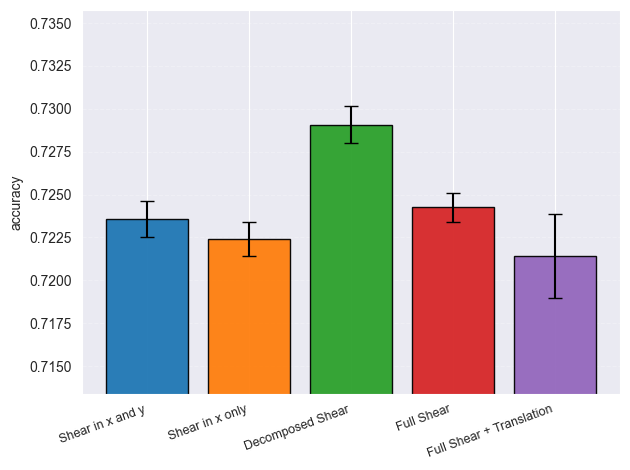


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\resnet_small\different_domain_cd\resnet_small_all_results_summary.tex`

\begin{table}
\caption{resnet_small All results (mean ± SE)}
\label{tab:resnet_small_all_results}
\begin{tabular}{llllll}
\toprule
 & Shear in x and y & Shear in x only & Decomposed Shear & Full Shear & Full Shear + Translation \\
Metric &  &  &  &  &  \\
\midrule
accuracy & 0.7236 ± 0.0010 & 0.7224 ± 0.0010 & 0.7291 ± 0.0011 & 0.7243 ± 0.0008 & 0.7214 ± 0.0024 \\
f2\_macro & 0.7186 ± 0.0012 & 0.7174 ± 0.0010 & 0.7239 ± 0.0012 & 0.7193 ± 0.0009 & 0.7163 ± 0.0025 \\
f2\_micro & 0.7236 ± 0.0010 & 0.7224 ± 0.0010 & 0.7291 ± 0.0011 & 0.7243 ± 0.0008 & 0.7214 ± 0.0024 \\
f2\_weighted & 0.7216 ± 0.0011 & 0.7204 ± 0.0010 & 0.7267 ± 0.0012 & 0.7223 ± 0.0009 & 0.7195 ± 0.0024 \\
\bottomrule
\end{tabular}
\end{table}



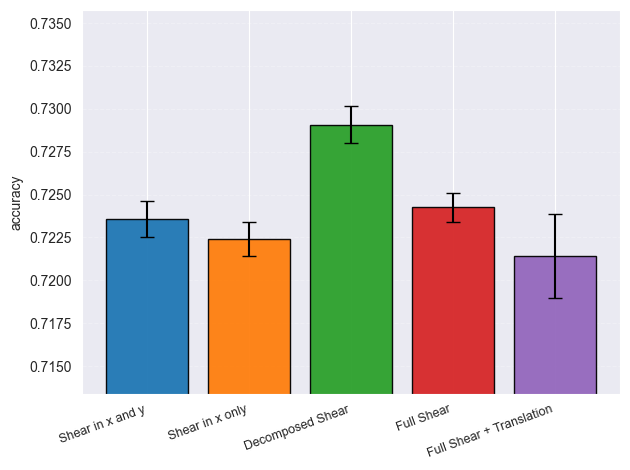


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\resnet_small\different_domain_cd\resnet_small_all_results_summary.tex`

\begin{table}
\caption{resnet_small All results (mean ± SE)}
\label{tab:resnet_small_all_results}
\begin{tabular}{llllll}
\toprule
 & Shear in x and y & Shear in x only & Decomposed Shear & Full Shear & Full Shear + Translation \\
Metric &  &  &  &  &  \\
\midrule
accuracy & 0.7236 ± 0.0010 & 0.7224 ± 0.0010 & 0.7291 ± 0.0011 & 0.7243 ± 0.0008 & 0.7214 ± 0.0024 \\
f2\_macro & 0.7186 ± 0.0012 & 0.7174 ± 0.0010 & 0.7239 ± 0.0012 & 0.7193 ± 0.0009 & 0.7163 ± 0.0025 \\
f2\_micro & 0.7236 ± 0.0010 & 0.7224 ± 0.0010 & 0.7291 ± 0.0011 & 0.7243 ± 0.0008 & 0.7214 ± 0.0024 \\
f2\_weighted & 0.7216 ± 0.0011 & 0.7204 ± 0.0010 & 0.7267 ± 0.0012 & 0.7223 ± 0.0009 & 0.7195 ± 0.0024 \\
\bottomrule
\end{tabular}
\end{table}



In [53]:
# python
# Build readable labels for result files and call the existing plotting helper.
import os
from utils.eval.vis import process_and_plot_groups

# directory containing the .json result files
# `results_dir_path` is expected to be defined earlier in the notebook
json_files = sorted([f for f in os.listdir(results_dir_path) if f.endswith(".json")])

# Optional: exclude the matrix result if present
json_files = [f for f in json_files if f != "random_search_knn_matrix.json"]

# explicit pretty names for known experiment files
pretty_names = {
    "random_search_knn_default": "Shear in x and y",
    "random_search_knn_shearscale": "Decomposed Shear",
    "random_search_knn_shearxy": "Full Shear",
    "random_search_knn_translation": "Full Shear + Translation",
    "random_search_knn_shear_x": "Shear in x only",
    "random_search_knn_matrix": "Random search — KNN (matrix)",
    # add more mappings as needed
}

def prettify_basename(basename: str) -> str:
    # fallback: convert snake_case to Title Case
    parts = basename.split("_")
    return " ".join(p.capitalize() for p in parts)

# items: list of tuples (label, filename) used by process_and_plot_groups
items = []
for fname in json_files:
    base = os.path.splitext(fname)[0]
    label = pretty_names.get(base, prettify_basename(base))
    #skip if not in pretty names
    if base not in pretty_names:
        continue
    items.append((label, fname))

if not items:
    print(f"No .json result files found in `{results_dir_path}`")
else:
    groups = [("all_results", "All results", items)]
    # call the plotting helper; keep `architecture` variable as before
    process_and_plot_groups(groups, results_dir_path, architecture, save_pgf=True,save_root=figure_path)
    process_and_plot_groups(groups, results_dir_path, architecture, save_pgf=False,save_root=figure_path)